In [1]:
import os
import re
import pickle
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [2]:
DATASET_PATH = "../data/processed/arxiv_15000_balanced.csv"

df = pd.read_csv(DATASET_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

Dataset shape: (15000, 5)
Columns: ['title', 'abstract', 'categories', 'main_category', 'text']


,title,abstract,categories,main_category,text
0,Spin glass models for a network of real neurons,Ising models with pairwise interactions are th...,q-bio.NC,Quantitative Biology,Spin glass models for a network of real neuron...
1,Relative-Error CUR Matrix Decompositions,Many data analysis applications deal with larg...,cs.DS,Computer Science,Relative-Error CUR Matrix Decompositions Many ...
2,Large-scale interval and point estimates from ...,The proposed approach extends the confidence p...,stat.ME math.ST q-bio.QM stat.AP stat.TH,Statistics,Large-scale interval and point estimates from ...
3,A binary model for the UV-upturn of elliptical...,The discovery of a flux excess in the far-ultr...,astro-ph,Physics,A binary model for the UV-upturn of elliptical...
4,Building Decision Procedures in the Calculus o...,It is commonly agreed that the success of futu...,cs.LO,Computer Science,Building Decision Procedures in the Calculus o...


In [3]:
title_col = "title" if "title" in df.columns else None
abstract_col = "abstract" if "abstract" in df.columns else None

if "main_category" in df.columns:
    label_col = "main_category"
elif "category" in df.columns:
    label_col = "category"
elif "categories" in df.columns:
    label_col = "categories"
else:
    raise ValueError("No category column found. Check dataset columns.")

print("Title column:", title_col)
print("Abstract column:", abstract_col)
print("Label column:", label_col)

Title column: title
Abstract column: abstract
Label column: main_category


In [4]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nClass distribution:")
print(df[label_col].value_counts())

Dataset shape: (15000, 5)

Missing values:
title            0
abstract         0
categories       0
main_category    0
text             0
dtype: int64

Duplicate rows:
44

Class distribution:
main_category
Quantitative Biology    2500
Computer Science        2500
Statistics              2500
Physics                 2500
Mathematics             2500
Quantitative Finance    2500
Name: count, dtype: int64


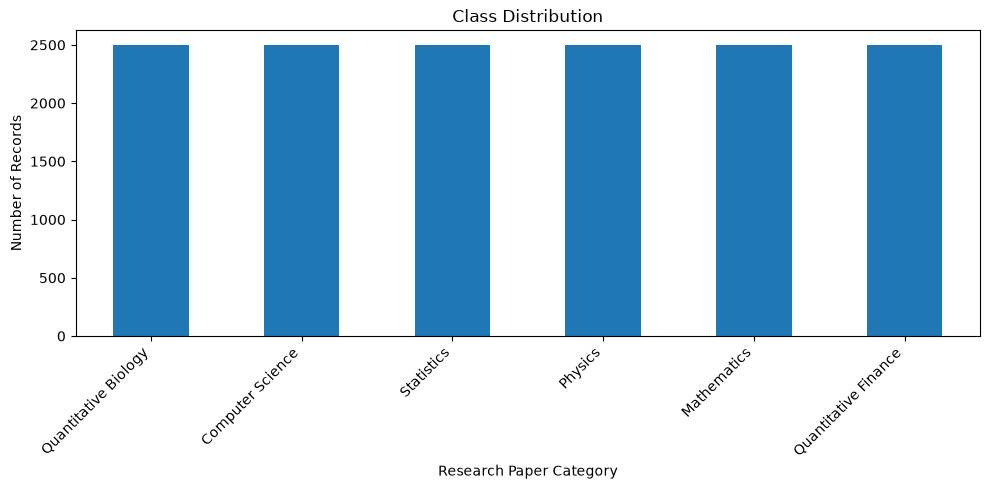

In [5]:
plt.figure(figsize=(10, 5))
df[label_col].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Research Paper Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

count    15000.000000
mean       128.268333
std         62.128933
min          2.000000
25%         82.000000
50%        121.000000
75%        169.000000
max        457.000000
Name: abstract_length, dtype: float64


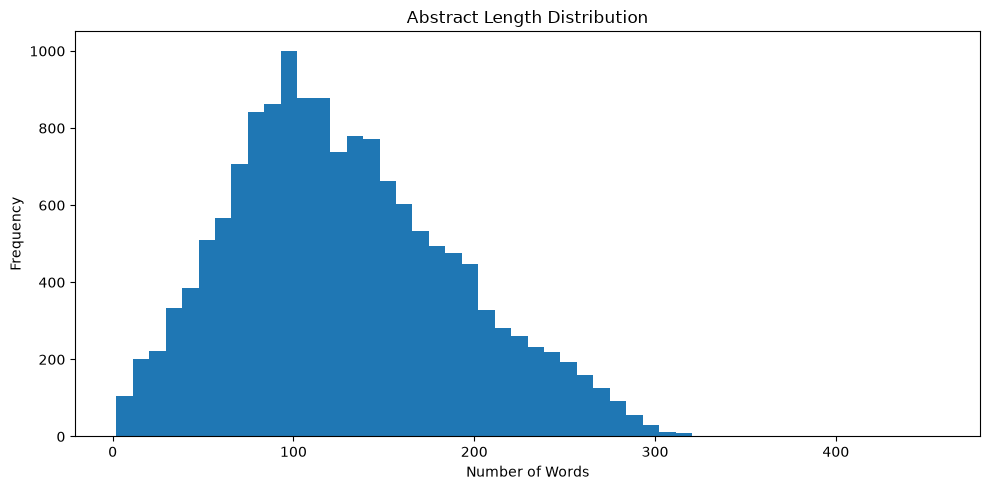

In [6]:
df["abstract_length"] = df[abstract_col].astype(str).apply(lambda x: len(x.split()))

print(df["abstract_length"].describe())

plt.figure(figsize=(10, 5))
plt.hist(df["abstract_length"], bins=50)
plt.title("Abstract Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [7]:
def clean_for_word_count(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    words = text.split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 2]
    return words

all_words = []

for text in df[abstract_col].astype(str):
    all_words.extend(clean_for_word_count(text))

word_counts = Counter(all_words)
common_words = word_counts.most_common(20)

common_df = pd.DataFrame(common_words, columns=["word", "count"])
common_df

,word,count
0,model,8651
1,data,5726
2,time,5213
3,paper,4585
4,results,4463
5,based,4342
6,using,4115
7,models,4054
8,problem,3316
9,method,3293


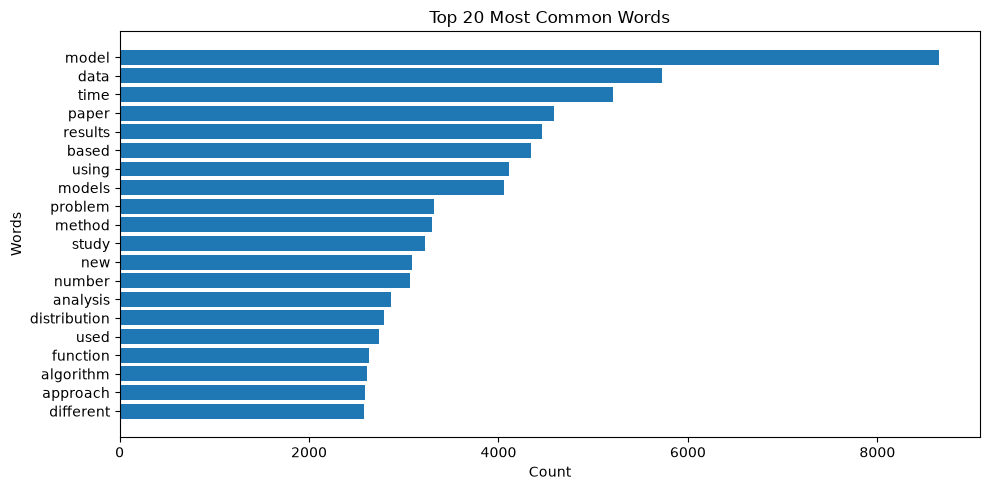

In [8]:
plt.figure(figsize=(10, 5))
plt.barh(common_df["word"], common_df["count"])
plt.title("Top 20 Most Common Words")
plt.xlabel("Count")
plt.ylabel("Words")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [9]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Combine title + abstract
if title_col:
    df["text"] = df[title_col].astype(str) + " " + df[abstract_col].astype(str)
else:
    df["text"] = df[abstract_col].astype(str)

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text", label_col]].head()

,text,clean_text,main_category
0,Spin glass models for a network of real neuron...,spin glass models for a network of real neuron...,Quantitative Biology
1,Relative-Error CUR Matrix Decompositions Many ...,relative error cur matrix decompositions many ...,Computer Science
2,Large-scale interval and point estimates from ...,large scale interval and point estimates from ...,Statistics
3,A binary model for the UV-upturn of elliptical...,a binary model for the uv upturn of elliptical...,Physics
4,Building Decision Procedures in the Calculus o...,building decision procedures in the calculus o...,Computer Science


In [10]:
X = df["clean_text"]
y = df[label_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 12000
Testing records: 3000


In [11]:
svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=30000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("svm", LinearSVC())
])

svm_model.fit(X_train, y_train)

print("SVM model training completed.")

SVM model training completed.


In [12]:
y_pred_svm = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9013333333333333

Classification Report:
                      precision    recall  f1-score   support

    Computer Science       0.88      0.85      0.86       500
         Mathematics       0.87      0.91      0.89       500
             Physics       0.94      0.89      0.91       500
Quantitative Biology       0.90      0.92      0.91       500
Quantitative Finance       0.96      0.95      0.96       500
          Statistics       0.86      0.89      0.87       500

            accuracy                           0.90      3000
           macro avg       0.90      0.90      0.90      3000
        weighted avg       0.90      0.90      0.90      3000



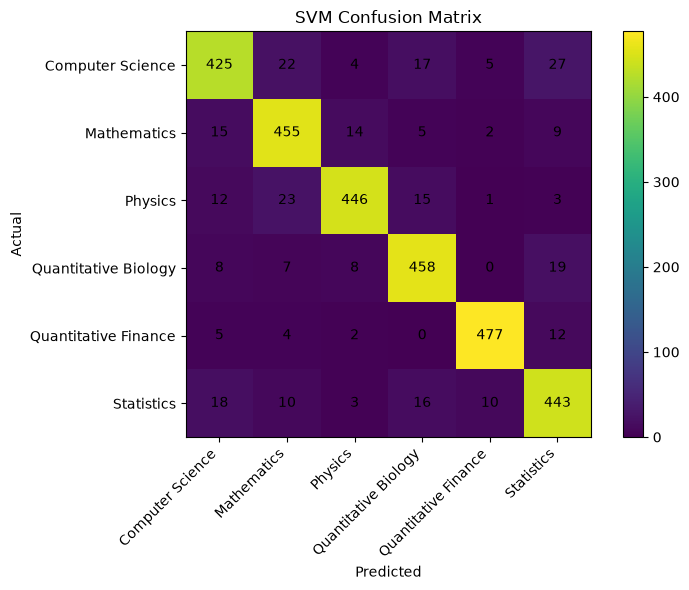

In [13]:
labels = svm_model.classes_
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm_svm)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)
plt.colorbar()

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm_svm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [14]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [15]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df[label_col])

print("Classes:")
print(label_encoder.classes_)
print("Number of classes:", len(label_encoder.classes_))

Classes:
['Computer Science' 'Mathematics' 'Physics' 'Quantitative Biology'
 'Quantitative Finance' 'Statistics']
Number of classes: 6


In [16]:
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    df["clean_text"],
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("CNN train size:", X_train_cnn.shape[0])
print("CNN test size:", X_test_cnn.shape[0])

CNN train size: 12000
CNN test size: 3000


In [17]:
max_words = 30000
max_len = 300

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_cnn)

X_train_seq = tokenizer.texts_to_sequences(X_train_cnn)
X_test_seq = tokenizer.texts_to_sequences(X_test_cnn)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

print("Train padded shape:", X_train_pad.shape)
print("Test padded shape:", X_test_pad.shape)

Train padded shape: (12000, 300)
Test padded shape: (3000, 300)


In [19]:
from tensorflow.keras.layers import Input

num_classes = len(label_encoder.classes_)

cnn_model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=max_words, output_dim=128),
    Conv1D(filters=128, kernel_size=5, activation="relu"),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 296, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,930,694 (14.99 MB)

 Trainable params: 3,930,694 (14.99 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = cnn_model.fit(
    X_train_pad,
    y_train_cnn,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - accuracy: 0.2894 - loss: 1.6902 - val_accuracy: 0.6858 - val_loss: 1.1809
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - accuracy: 0.7423 - loss: 0.8200 - val_accuracy: 0.8442 - val_loss: 0.5030
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - accuracy: 0.8750 - loss: 0.4258 - val_accuracy: 0.8775 - val_loss: 0.4165
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.9304 - loss: 0.2487 - val_accuracy: 0.8746 - val_loss: 0.4199
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - accuracy: 0.9616 - loss: 0.1518 - val_accuracy: 0.8804 - val_loss: 0.4305


In [21]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_pad, y_test_cnn)

print("CNN Test Loss:", cnn_loss)
print("CNN Test Accuracy:", cnn_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8707 - loss: 0.4647
CNN Test Loss: 0.4647459387779236
CNN Test Accuracy: 0.8706666827201843


In [22]:
y_pred_prob = cnn_model.predict(X_test_pad)
y_pred_cnn = np.argmax(y_pred_prob, axis=1)

print(classification_report(
    y_test_cnn,
    y_pred_cnn,
    target_names=label_encoder.classes_
))

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
                      precision    recall  f1-score   support

    Computer Science       0.84      0.80      0.82       500
         Mathematics       0.85      0.90      0.88       500
             Physics       0.92      0.86      0.89       500
Quantitative Biology       0.88      0.88      0.88       500
Quantitative Finance       0.93      0.93      0.93       500
          Statistics       0.82      0.85      0.83       500

            accuracy                           0.87      3000
           macro avg       0.87      0.87      0.87      3000
        weighted avg       0.87      0.87      0.87      3000



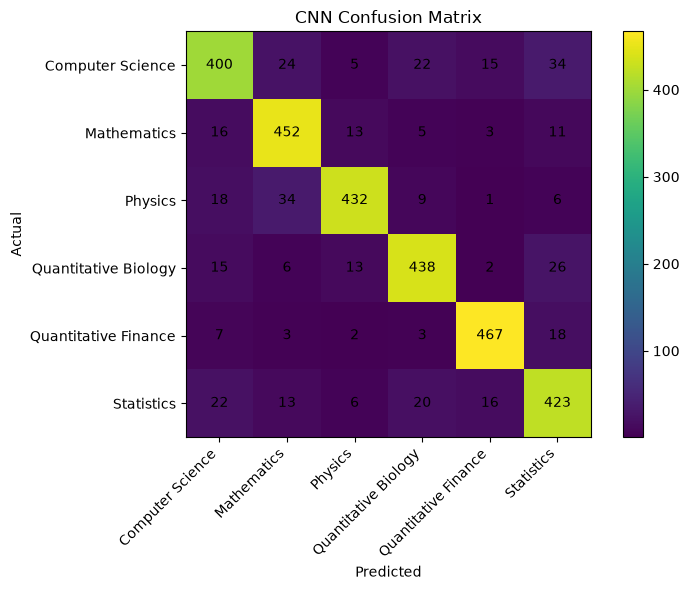

In [23]:
cm_cnn = confusion_matrix(y_test_cnn, y_pred_cnn)

plt.figure(figsize=(8, 6))
plt.imshow(cm_cnn)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45, ha="right")
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)
plt.colorbar()

for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        plt.text(j, i, cm_cnn[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

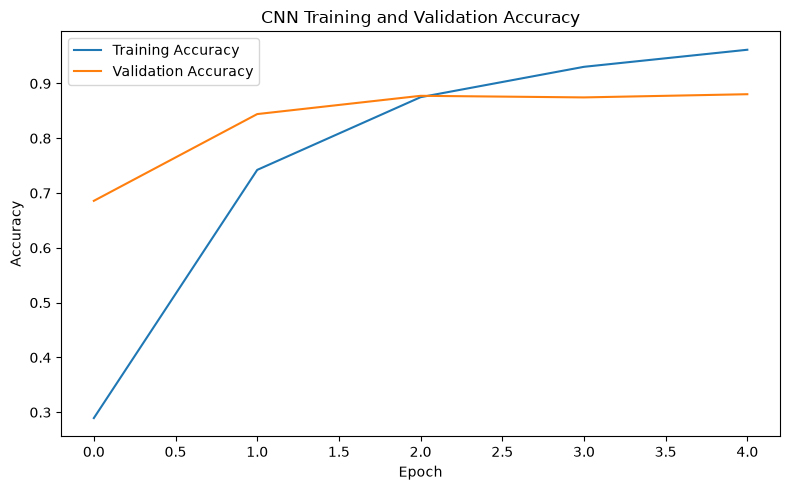

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
import os
import joblib
import pickle

os.makedirs("../models", exist_ok=True)
os.makedirs("../screenshots/member2", exist_ok=True)

joblib.dump(svm_model, "../models/member2_svm_model.pkl")
joblib.dump(label_encoder, "../models/member2_label_encoder.pkl")

cnn_model.save("../models/member2_cnn_model.h5")

with open("../models/member2_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Member 2 models saved successfully.")

Member 2 models saved successfully.


In [26]:
print("Member 2 Final Results")
print("----------------------")
print("ML Model  : Linear SVM")
print("SVM Accuracy:", svm_accuracy)
print()
print("DL Model  : CNN")
print("CNN Accuracy:", cnn_accuracy)
print()
print("Dataset:", DATASET_PATH)
print("Total Records:", len(df))
print("Classes:", list(label_encoder.classes_))

Member 2 Final Results
----------------------
ML Model  : Linear SVM
SVM Accuracy: 0.9013333333333333

DL Model  : CNN
CNN Accuracy: 0.8706666827201843

Dataset: ../data/processed/arxiv_15000_balanced.csv
Total Records: 15000
Classes: ['Computer Science', 'Mathematics', 'Physics', 'Quantitative Biology', 'Quantitative Finance', 'Statistics']
